# Limit contour: event list → excluded $(m_\text{DM}, \alpha_n)$ region

**Private.** Successor to `12_limit_atmos`, with the limit set by the public
[`optimum_interval`](https://github.com/tunnell/optimum_interval) package
instead of the $\langle N\rangle = 3$ rule, so observed candidate events are
handled without a background model.

**Input:** the `EVENTS` array of reconstructed kick momenta (here one random
toy candidate). *Replacing that array with data is the only change needed to
run the real analysis.* **Output:** the 95% CL excluded
$(m_\text{DM}, \alpha_n)$ island and the machine-readable
`limit_contour_data.npz`.

The notebook is a pipeline, one section each:

1. **Physics model**: SHM halo at the top of the atmosphere (`luhdm.halo`);
   attenuation ODE → detector-frame $f(v)$ carrying the survival fraction
   (`luhdm.atmosphere`); classical $K_1$-impulse cross section from a
   finite-range Yukawa on the finite-size magnet (`luhdm.cross_section`);
   assembled into $dR/dq = n_\text{DM}\int f(v)\,v\,(d\sigma/dq)\,dv$ by
   `differential_rate_trapz` *in this notebook*; it is the formula you tweak.
2. **Statistics**: at each $(m_\text{DM}, \alpha_n)$ grid point, the expected
   count $\mu$ and normalized spectrum shape feed the optimum-interval
   **extremeness** (`luhdm.limits`). Because the spectrum shape itself depends
   on the coupling (finite range, attenuation), the limit is a **level set of
   the extremeness surface**, not a single $\mu$ solve.
3. **Results**: the excluded island for $\lambda$ = 3 mm and the massless
   comparison.
4. **Understanding**: why the island has the shape it does: every edge
   explained, plus transit-count and reach maps up to the Planck mass.
   *Pedagogical: nothing there feeds the limit.*
5. **Output**: `limit_contour_data.npz`: grids, surfaces, contour polylines.
6. **Appendix**: validation against closed forms and spot checks along the
   contour.


In [1]:
%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import atmosphere, config, cross_section, halo, limits, units

# fiducials, as in 12_limit_atmos cell 18
LAMB = 3e-3                       # mediator range [m]
R_eff = config.R_EFF
Q_THRESH = config.Q_THRESH
T_TOTAL = 3600 * 24 * 7 * 2      # 2 weeks in seconds
CONFIDENCE = 0.95

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    si = f"{lamb_m * 1e3:.0f} mm" if lamb_m < 1 else f"{lamb_m:.0f} m"
    return rf"$\lambda$ = {si} = ${x / 10**e:.1f}\times10^{{{e}}}$ GeV$^{{-1}}$"


np.random.seed(20260702)         # luhdm samplers use legacy np.random
print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"xi = {R_eff / LAMB:.3f}")

N_n = 2.51e+20   q_th = 8400 GeV   xi = 0.067


## Input: the event list

One candidate kick drawn at random just above threshold. **Replace this array
with the reconstructed kicks from data and rerun; nothing else changes.**


In [2]:
rng = np.random.default_rng(20260702)
EVENTS = 10 ** rng.uniform(np.log10(Q_THRESH), np.log10(3 * Q_THRESH), size=1)
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [12625.]


## Physics model

### Cross-section interpolant

One-time tabulation of the dimensionless $d\sigma/d\tilde q$ (provided by
`luhdm.cross_section`, same call as in `12_limit_atmos`).


In [3]:
print("Computing dsigma_dq interpolant...")
interpolant = cross_section.make_dsigma_dq_interpolant(1e-25, R_eff, LAMB)
print("Done")

Computing dsigma_dq interpolant...


  0%|          | 0/1000 [00:00<?, ?it/s]

~/code/luhdm/luhdm/cross_section.py:302: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, _ = quad(integrand, 0, t_max, limit=100)
~/code/luhdm/luhdm/cross_section.py:302: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(integrand, 0, t_max, limit=100)
  0%|          | 3/1000 [00:00<00:45, 22.04it/s]

  1%|          | 6/1000 [00:00<00:49, 20.23it/s]

  1%|          | 9/1000 [00:00<00:47, 20.76it/s]

...

 93%|█████████▎| 930/1000 [00:27<00:00, 83.89it/s]

 94%|█████████▍| 940/1000 [00:27<00:00, 86.62it/s]

 95%|█████████▌| 953/1000 [00:27<00:00, 96.04it/s]

100%|██████████| 1000/1000 [00:27<00:00, 36.12it/s]

Done


### Differential rate: the physics to tweak

Same formula and notation as `12_limit_atmos` (`mu` is the DM mass in the
original notation); only the rate conversion constant moved to `luhdm.units`.
`expected_transits` (used in the Understanding section and the appendix) is
the companion flux integral: the number of particles passing within the
threshold reach $b_\text{max}$ during the exposure.


In [4]:
def differential_rate_trapz(qs, alpha_n, lamb, mu, R_eff, f_v_f, dsigma_interpolant):
    '''dR/dq via trapz (mu = m_DM in the original notation).'''
    alpha = alpha_n * config.N_NEUTRONS
    n_dm = halo.number_density_dm(mu)

    # Precompute f_vf on a fixed grid spanning all v_mins
    v_min_global = qs.min() / mu
    vs_global = np.geomspace(v_min_global, config.VESC, 500)
    f_vf_grid = f_v_f(vs_global)  # KDE evaluated once

    results = []
    for q in qs:
        v_min = q / mu
        mask = vs_global >= v_min
        vs = vs_global[mask]
        fvf = f_vf_grid[mask]
        integrand = n_dm * fvf * vs * cross_section.dsigma_dq(
            q, alpha, lamb, R_eff, vs, dsigma_interpolant)
        results.append(np.trapezoid(integrand, vs) * units.CONV2RATE)

    return np.maximum(np.array(results), 0)


v_i_samples = atmosphere.sample_shm(int(1e5))  # SHM at the top of the atmosphere


def expected_transits(alpha_n, mu, f_v_f):
    # expected flybys within the threshold reach during the exposure (mu = m_DM)
    alpha = alpha_n * config.N_NEUTRONS
    vs = np.geomspace(max(Q_THRESH / mu, 1e-8), config.VESC, 300)
    b = cross_section.impact_parameter_max(Q_THRESH, alpha, LAMB, R_eff, vs)
    n_m3 = 0.3 / mu * 1e6  # rho = 0.3 GeV/cm^3 -> 1/m^3
    return T_TOTAL * np.trapezoid(
        f_v_f(vs) * n_m3 * (vs * units.C_M_S) * np.pi * b**2, vs)

### Spectra

The attenuated $dR/dq$ for a few masses at fixed coupling (the analog of the
spectra figure in `12_limit_atmos`).


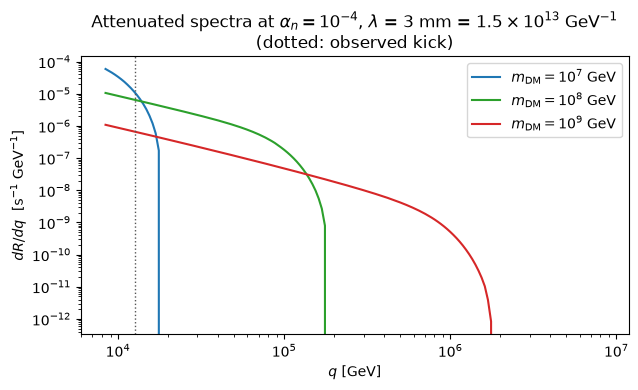

In [5]:
ALPHA_N_SHOW = 1e-4
qs_plot = np.geomspace(Q_THRESH, 1000 * Q_THRESH, 160)

fig, ax = plt.subplots(figsize=(6.5, 4))
for m, color in [(1e7, "#1f77b4"), (1e8, "#2ca02c"), (1e9, "#d62728")]:
    v_min = qs_plot.min() / m / 10
    v_f_samples = atmosphere.compute_v_f_distribution(
        ALPHA_N_SHOW, LAMB, m, v_i_samples, v_min=v_min, n_grid=80)
    f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
    ax.loglog(qs_plot,
              differential_rate_trapz(qs_plot, ALPHA_N_SHOW, LAMB, m, R_eff,
                                      f_v_f, interpolant),
              color=color, label=rf"$m_{{\rm DM}} = 10^{{{int(np.log10(m))}}}$ GeV")
for q_ev in EVENTS:
    ax.axvline(q_ev, color="#555555", lw=1, ls=":")
ax.set_xlabel(r"$q$ [GeV]")
ax.set_ylabel(r"$dR/dq$  [s$^{-1}$ GeV$^{-1}$]")
ax.set_title(rf"Attenuated spectra at $\alpha_n = 10^{{-4}}$, " + lamb_label(LAMB)
             + "\n(dotted: observed kick)")
ax.legend()
fig.tight_layout()

## Statistics: what the extremeness means

At each grid point the extremeness is

$$p = \Pr\big(C_\text{max}^\text{pseudo} < C_\text{max}^\text{obs}\,\big|\,m_\text{DM}, \alpha_n,\ \text{no background}\big),$$

the fraction of background-free pseudo-experiments generated *under that
hypothesis* whose most-anomalously-empty spectral stretch looks **less** empty
than the data. Physically: $p = 0.95$ means the hypothesis predicts enough
events that 95% of the time our gaps would have been filled in more than they
are: the observed emptiness sits in the 5% tail, so the point is excluded at
95% CL. The surface *is* the confidence level: the rule "exclude where
$p \ge C$" wrongly rejects a true hypothesis at most $(1-C)$ of the time
(frequentist coverage, not a posterior probability), and any CL is a level set
of the same array; the 90% contour needs no rescan. The test is one-sided by
construction: background can only *add* events, filling gaps and lowering $p$,
so backgrounds can weaken an exclusion but never fake one.


## The $(m_\text{DM}, \alpha_n)$ scan

Same double loop as the `counts` grid in `12_limit_atmos`, storing three
surfaces: `counts` (expected events $\mu$, exactly as before), `extremeness`
(the optimum-interval statistic for `EVENTS`, from `luhdm.limits`), and
`N_T` (expected transits, exported with the results). Monte-Carlo
calibration tables are shared across the plane via $\mu$ rounding.


In [6]:
# Prefer the high-fidelity scan from scripts/scan_grid.py (run on a many-core
# node) if its output is present; otherwise run a coarse scan inline.
# Grid rationale: masses from just below the kinematic floor q_th/v_esc
# ~ 4.6e6 GeV out past the finite-range pinch-off at ~3e13 GeV (where the
# logarithmically saturating reach can no longer offset the 1/m fall of the
# number density -- see Understanding); couplings follow the atmospheric
# ceiling (~ sqrt(m)) -- alpha_n > 1 appears only to show the island close.
RESULTS = Path("scan_results.npz")
if RESULTS.exists():
    d = np.load(RESULTS)
    ms, alphas_n = d["ms"], d["alphas_n"]
    extremeness, counts = d["extremeness"], d["counts"]
    N_T = np.maximum(d["n_transit"], 0.0) if "n_transit" in d.files else None
    # (clip: the KDE tail can oscillate slightly negative below the kinematic floor)
    assert np.allclose(d["events"], EVENTS), "scan used a different event list!"
    print(f"loaded {RESULTS}: {ms.size} masses x {alphas_n.size} couplings, "
          f"fidelity {d['fidelity']}")
else:
    ms = np.logspace(6.6, np.log10(1.22e19), 19)
    alphas_n = np.logspace(-8.5, 0.0, 30)
    counts = np.zeros((alphas_n.size, ms.size))
    extremeness = np.zeros((alphas_n.size, ms.size))
    N_T = np.zeros((alphas_n.size, ms.size))
    table = limits.new_table(seed=20260702)
    t0 = time.time()
    for im, m in enumerate(ms):
        for ia, alpha_n in enumerate(alphas_n):
            v_min = Q_THRESH / m / 10
            v_f_samples = atmosphere.compute_v_f_distribution(
                alpha_n, LAMB, m, v_i_samples, v_min=v_min, n_grid=80)
            f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
            qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
            diff_rate = differential_rate_trapz(qs, alpha_n, LAMB, m, R_eff,
                                                f_v_f, interpolant)
            extremeness[ia, im], counts[ia, im] = limits.extremeness_and_mu(
                table, EVENTS, qs, diff_rate, T_TOTAL)
            N_T[ia, im] = expected_transits(alpha_n, m, f_v_f)
    print(f"inline scan: {time.time() - t0:.0f}s")

loaded scan_results.npz: 60 masses x 44 couplings, fidelity {'n_ode': 400, 'n_shm': 300000, 'n_q': 240, 'q_span': 30000.0, 'n_mc': 10000, 'n_m': 60, 'n_a': 44}


## Results: the excluded island

Solid: the 95% CL optimum-interval contour given `EVENTS`. Dashed: the
$\langle N\rangle = 3$ zero-event contour (the old rule) from the same
`counts` surface. The excluded region is an island; each edge is explained in
"Understanding the island" below.

Note the dashed contour pokes out past the red one near the floor and the
left edge: there the (narrow) kinematic window contains the observed kick, so
the honest one-event limit is weaker than the zero-event rule, which simply
does not apply once there is a candidate. Where the window excludes the event
the two coincide.


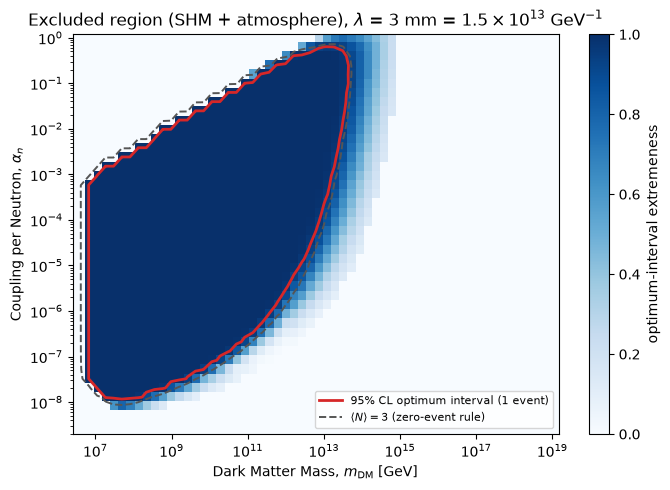

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(ms, alphas_n, extremeness, cmap="Blues",
                     vmin=0, vmax=1, shading="auto")
fig.colorbar(mesh, ax=ax, label="optimum-interval extremeness")
cs95 = ax.contour(ms, alphas_n, extremeness, levels=[CONFIDENCE],
                  colors="#d62728", linewidths=2)
cs3 = ax.contour(ms, alphas_n, counts, levels=[3.0], colors="#555555",
                 linewidths=1.4, linestyles="--")
ax.plot([], [], color="#d62728", lw=2,
        label=f"{CONFIDENCE:.0%} CL optimum interval ({EVENTS.size} event)")
ax.plot([], [], color="#555555", lw=1.4, ls="--",
        label=r"$\langle N\rangle = 3$ (zero-event rule)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
ax.set_title("Excluded region (SHM + atmosphere), " + lamb_label(LAMB))
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig("limit_contour.png", dpi=140)

### Massless vs finite range

The companion scan (`scripts/scan_grid.py --lamb 3.0`; $\lambda$ = 3 m is
effectively massless at all detector scales while keeping the atmospheric
Coulomb logarithm regulated) sets the same limit for a massless mediator. As
$\lambda \to \infty$: $G_2 \to 1$, $K_1(x) \to 1/x$, the impulse becomes
Coulomb-like $q(b) = 2\alpha/(bv)$, and the projected cross section collapses
to the closed form $d\sigma/dq = 2\pi\alpha^2/(v^2 q^3)$
(`cross_section_rutherford_projection`); the $1/q^3$ shape no longer depends
on $\alpha_n$; only the atmosphere still couples the spectrum to the
coupling. Convergence of the $K_1$ machinery to this closed form is verified
in the appendix.

The contrast to notice: the finite-range island pinches off at high mass,
while the massless island is an **open band**: floor and ceiling both rising
as $\sqrt{m}$ with **no high-mass endpoint**. The next section explains both.


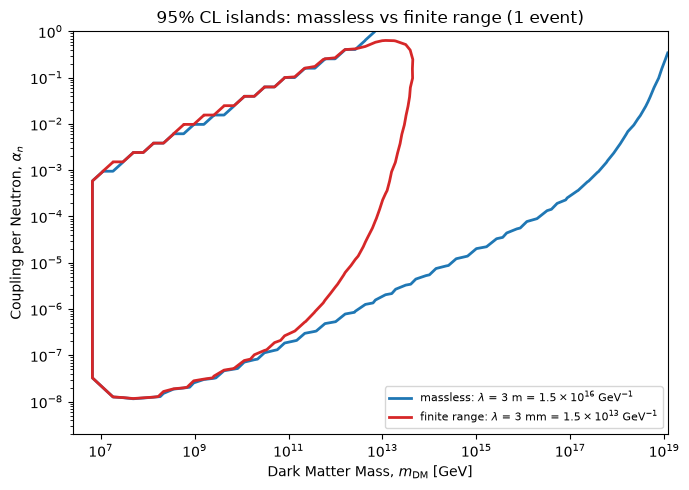

In [8]:
CS95_ML = None
ML = Path("scan_results_massless.npz")
if ML.exists():
    dml = np.load(ML)
    assert np.allclose(dml["events"], EVENTS)
    fig, ax = plt.subplots(figsize=(7, 5))
    CS95_ML = ax.contour(dml["ms"], dml["alphas_n"], dml["extremeness"],
                         levels=[CONFIDENCE], colors="#1f77b4", linewidths=2)
    ax.contour(ms, alphas_n, extremeness, levels=[CONFIDENCE],
               colors="#d62728", linewidths=2)
    ax.plot([], [], color="#1f77b4", lw=2,
            label="massless: " + lamb_label(float(dml["lamb"])))
    ax.plot([], [], color="#d62728", lw=2,
            label="finite range: " + lamb_label(LAMB))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
    ax.set_title(f"{CONFIDENCE:.0%} CL islands: massless vs finite range "
                 f"({EVENTS.size} event)")
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    fig.savefig("limit_contour_compare.png", dpi=140)
else:
    print("scan_results_massless.npz not found; "
          "run scripts/scan_grid.py --lamb 3.0")

## Understanding the island

*Everything in this section is pedagogical; none of it feeds the limit.*
Every edge of the excluded region has a one-line explanation (scalings at
fixed exposure):

- **Left edge (kinematic floor).** Below
  $m = q_\text{th}/v_\text{esc} \approx 4.6\times10^6$ GeV even an
  escape-velocity particle cannot deliver the threshold kick, at any coupling.
- **Bottom edge (statistics floor).** The smallest coupling with
  $\mu \gtrsim 3$ expected events. The rate scales as
  $\alpha^2 n_\text{DM} \propto \alpha^2/m$, so the floor rises as
  $\alpha_\text{min} \propto \sqrt{m}$.
- **Top edge (atmospheric ceiling).** Stopping power also scales as
  $\alpha^2/m$: above the ceiling particles arrive below threshold speed, so
  the ceiling rises $\propto \sqrt{m}$ (up to a Coulomb log) and the band
  between floor and ceiling stays open.
- **Right edge (finite range only).** The reach saturates logarithmically,
  $b_\text{max} = \lambda\,K_1^{-1}(\tilde q) \approx
  \lambda\ln\!\big(2\alpha G_2/(q_\text{th}\lambda v)\big)$, a few cm for
  $\lambda$ = 3 mm no matter the coupling. Past
  $m \approx 3\times10^{13}$ GeV no coupling can buy back the $1/m$ fall of
  the number density, $\mu$ drops below 3, and the island pinches off.
- **Massless (no right edge).** The Coulomb reach grows as a *power law*,
  $b_\text{max} = 2\alpha/(q_\text{th} v)$, so extra coupling always restores
  the event count: **there is no in-model high-mass cutoff**, matching the
  $m_\phi = 0$ curves of Monteiro et al., PRL 125, 181102 (arXiv:2007.12067).
  What ends instead is *validity*: the reach passes ~10 cm at $10^{15}$ GeV
  and ~1 m at $10^{17}$ GeV, beyond any apparatus scale (see the maps
  below).

The maps below make these statements visible.


### Transit-count and reach maps up to the Planck mass

**Top row:** color is $\log_{10} N_t$, the expected number of particles passing
within $\pi b_\text{max}^2$ during the exposure (halo flux, no attenuation;
the atmosphere only matters near the low-mass ceiling). White solid: $N_t = 1$;
white dashed: $N_t = 3$; red: the 95% exclusion contour from the scan. The
finite-range $N_t = 1$ boundary is a near-vertical wall (saturating reach);
the massless one is a $\sqrt{m}$ diagonal that continues to the Planck mass.

**Bottom row:** the flux-averaged threshold reach
$b_\text{max} = \sqrt{\langle b^2 \rangle}$ in meters, with contours at
everyday length scales. This is the aperture that converts flux into transits,
$N_t = \Phi \cdot \pi b_\text{max}^2 \cdot T$, and it answers "how can there
be transits at the Planck mass when the flux is only
$\sim 0.2\,/\mathrm{m}^2/\mathrm{yr}$": for the massless mediator the *formal*
reach at large coupling is macroscopic: $b_\text{max} = 2\alpha/(q_\text{th}
v) \sim 10$ km at $\alpha_n = 1$, an aperture of $\sim 10^9\,\mathrm{m}^2$,
so even $7 \times 10^{-3}$ per m$^2$ per exposure yields $N_t \sim 10^6$. The
finite-range reach saturates at $\lambda K_1^{-1} \sim$ cm, which is why its
$N_t = 1$ wall is real. Of course a 10 km "reach" is not an apparatus: capping
it at a laboratory scale $b_\text{cap}$ turns the falling flux into a hard,
coupling-independent endpoint at
$m_\text{end} = \rho\,\bar v\,\pi b_\text{cap}^2\,T \approx
2.5\times10^{15}\ \text{GeV} \times (b_\text{cap}/10\,\text{cm})^2\,
(T/2\,\text{wk})$.


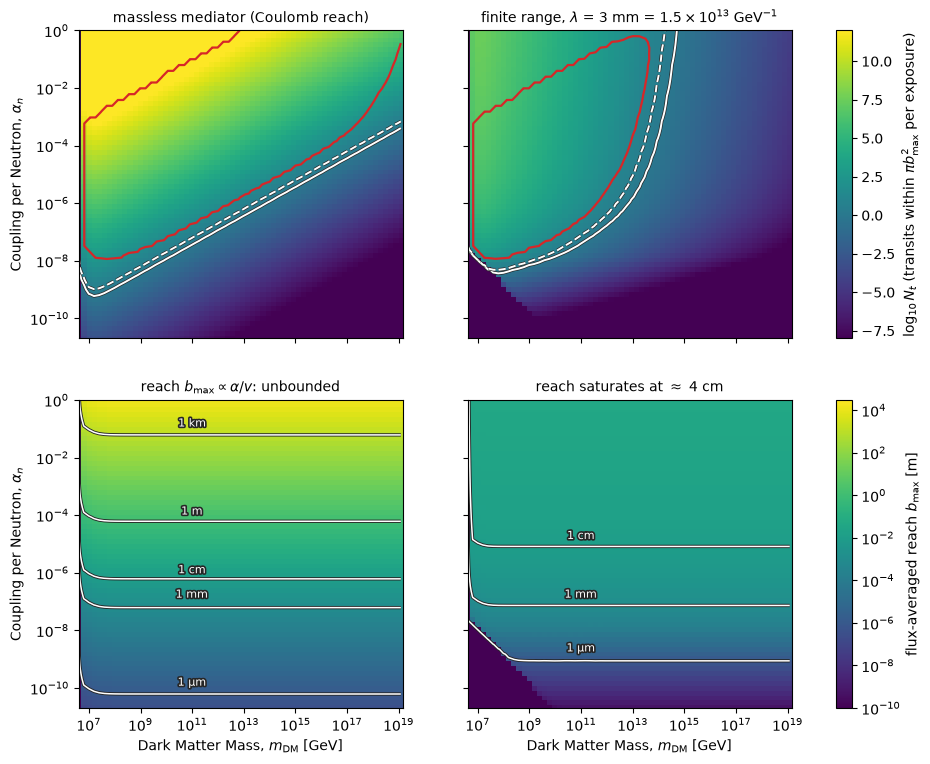

In [9]:
HBAR_C_M = 1.9733e-16  # GeV^-1 in meters

def transit_count_halo(m, alpha_n, lamb=None):
    # (N_t, flux-averaged pi*b_max^2 [m^2]) for the unattenuated halo flux;
    # lamb=None -> massless (analytic Coulomb reach)
    vs = np.geomspace(max(Q_THRESH / m, 1e-8), config.VESC, 200)
    if vs.size < 2 or vs[0] >= config.VESC:
        return 0.0, 0.0
    alpha = alpha_n * config.N_NEUTRONS
    if lamb is None:
        b = 2 * alpha / (Q_THRESH * vs) * HBAR_C_M
    else:
        b = cross_section.impact_parameter_max(Q_THRESH, alpha, lamb, R_eff, vs)
    flux_w = halo.standard_halo_model(vs) * (vs * units.C_M_S)
    area = np.pi * b**2
    n_m3 = 0.3 / m * 1e6
    nt = T_TOTAL * n_m3 * np.trapezoid(flux_w * area, vs)
    a_eff = np.trapezoid(flux_w * area, vs) / np.trapezoid(flux_w, vs)
    return nt, a_eff

M_PL = 1.22e19
ms_map = np.geomspace(4e6, M_PL, 64)
al_map = np.geomspace(2e-11, 1.0, 64)

def grids(lamb):
    out = np.array([[transit_count_halo(m, a, lamb) for m in ms_map]
                    for a in al_map])
    return out[:, :, 0], out[:, :, 1]

NT_ML_MAP, AEFF_ML_MAP = grids(None)
NT_FR_MAP, AEFF_FR_MAP = grids(LAMB)
B_ML_MAP = np.sqrt(AEFF_ML_MAP / np.pi)  # flux-averaged reach [m]
B_FR_MAP = np.sqrt(AEFF_FR_MAP / np.pi)

import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm, Normalize

def outline(artists):  # keep white lines/labels legible on any viridis shade
    for a in artists:
        a.set_path_effects([pe.Stroke(linewidth=2.4, foreground="0.15"),
                            pe.Normal()])

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.8), sharex=True, sharey=True)
norm_nt = Normalize(vmin=-8, vmax=12)
norm_b = LogNorm(vmin=1e-10, vmax=3e4)
B_LEVELS = [1e-6, 1e-3, 1e-2, 1.0, 1e3]
B_NAMES = {1e-6: "1 µm", 1e-3: "1 mm", 1e-2: "1 cm", 1.0: "1 m", 1e3: "1 km"}
titles = ["massless mediator (Coulomb reach)", "finite range, " + lamb_label(LAMB)]

for j, (NT_MAP, B_MAP) in enumerate([(NT_ML_MAP, B_ML_MAP),
                                     (NT_FR_MAP, B_FR_MAP)]):
    ax = axes[0, j]
    z = np.log10(np.clip(NT_MAP, 1e-8, 1e12))
    mesh_nt = ax.pcolormesh(ms_map, al_map, z, cmap="viridis", norm=norm_nt,
                            shading="auto")
    for lev, ls in [(1.0, "-"), (3.0, "--")]:
        cs = ax.contour(ms_map, al_map, NT_MAP, levels=[lev], colors="w",
                        linewidths=1.4, linestyles=ls)
        outline(getattr(cs, "collections", [cs]))
    ax.set_title(titles[j], fontsize=10)

    ax = axes[1, j]
    mesh_b = ax.pcolormesh(ms_map, al_map, np.clip(B_MAP, 1e-10, None),
                           cmap="viridis", norm=norm_b, shading="auto")
    cs = ax.contour(ms_map, al_map, B_MAP, levels=B_LEVELS, colors="w",
                    linewidths=1.1)
    outline(getattr(cs, "collections", [cs]))
    # label each level just above its line, mid-plot (the lines are
    # horizontal away from the kinematic floor)
    col = np.argmin(np.abs(ms_map - 1e11))
    for lev in cs.levels:
        miss = np.abs(np.log10(B_MAP[:, col] / lev))
        if miss.min() < 0.3:
            y = al_map[miss.argmin()]
            txt = ax.text(1e11, y * 1.5, B_NAMES[lev], fontsize=8, color="w",
                          ha="center", va="bottom")
            outline([txt])
    note = (r"reach $b_{\rm max} \propto \alpha/v$: unbounded" if j == 0 else
            r"reach saturates at $\approx$ "
            + f"{B_MAP.max() * 100:.0f} cm")
    ax.set_title(note, fontsize=10)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")

# overlay the 95% exclusion contours from the scans where available
axes[0, 1].contour(ms, alphas_n, extremeness, levels=[CONFIDENCE],
                   colors="#d62728", linewidths=1.6)
ML0 = Path("scan_results_massless.npz")
if ML0.exists():
    dml0 = np.load(ML0)
    axes[0, 0].contour(dml0["ms"], dml0["alphas_n"], dml0["extremeness"],
                       levels=[CONFIDENCE], colors="#d62728", linewidths=1.6)

for ax in axes[:, 0]:
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
axes[0, 0].set_ylim(al_map[0], 1.0)
fig.colorbar(mesh_nt, ax=axes[0, :], label=r"$\log_{10} N_t$ (transits within "
                                           r"$\pi b_{\rm max}^2$ per exposure)")
fig.colorbar(mesh_b, ax=axes[1, :],
             label=r"flux-averaged reach $b_{\rm max}$ [m]")
fig.savefig("flux_map.png", dpi=140, bbox_inches="tight")

## Machine-readable output

Everything on the plots, written to `limit_contour_data.npz` so nobody ever
has to digitize a figure: axis grids, the 2D surfaces (extremeness, counts,
transits, plus the Planck-range understanding maps), the event list, and the
contour lines as NaN-separated (m, alpha_n) polylines.


In [10]:
def contour_polyline(cs):
    # all segments of a single-level contour as one NaN-separated (N, 2) array
    parts = []
    for seg in cs.allsegs[0]:
        parts.append(seg)
        parts.append(np.full((1, 2), np.nan))
    return np.vstack(parts) if parts else np.empty((0, 2))


extra = {}
if CS95_ML is not None:
    extra["contour_95_massless"] = contour_polyline(CS95_ML)
if N_T is not None:
    extra["n_transit"] = N_T
extra["nt_map_ms"] = ms_map
extra["nt_map_alphas"] = al_map
extra["nt_map_massless"] = NT_ML_MAP
extra["nt_map_finite"] = NT_FR_MAP
extra["nt_map_area_massless"] = AEFF_ML_MAP
extra["nt_map_area_finite"] = AEFF_FR_MAP
np.savez(
    "limit_contour_data.npz",
    ms=ms,                              # mass grid [GeV]
    alphas_n=alphas_n,                  # coupling grid
    extremeness=extremeness,            # optimum-interval extremeness surface
    counts=counts,                      # expected-event surface mu(m, alpha)
    events=EVENTS,                      # observed kicks [GeV]
    contour_95=contour_polyline(cs95),  # 95% CL line, columns (m, alpha_n)
    contour_n3=contour_polyline(cs3),   # <N>=3 line, columns (m, alpha_n)
    lamb=LAMB, t_total=T_TOTAL, confidence=CONFIDENCE,
    **extra,
)
d = np.load("limit_contour_data.npz")
print("limit_contour_data.npz:", {k: d[k].shape for k in d.files})

limit_contour_data.npz: {'ms': (60,), 'alphas_n': (44,), 'extremeness': (44, 60), 'counts': (44, 60), 'events': (1,), 'contour_95': (144, 2), 'contour_n3': (146, 2), 'lamb': (), 't_total': (), 'confidence': (), 'contour_95_massless': (164, 2), 'n_transit': (44, 60), 'nt_map_ms': (64,), 'nt_map_alphas': (64,), 'nt_map_massless': (64, 64), 'nt_map_finite': (64, 64), 'nt_map_area_massless': (64, 64), 'nt_map_area_finite': (64, 64)}


## Appendix: validation checks

Two checks that the machinery is wired correctly:

1. **$K_1$ → Coulomb convergence.** At $\lambda$ = 3 m and small coupling
   (threshold kicks come from close flybys, $b \ll \lambda$, the Coulomb
   regime), the tabulated $K_1$ machinery must reproduce the closed form
   $2\pi\alpha^2/(v^2 q^3)$. The ratios below should be $\approx 1$.
2. **Spot checks along the contour.** The reach
   $b_\text{max} = \lambda\,K_1^{-1}\!\big(q_\text{th}\lambda v/2\alpha G_2\big)$
   (`cross_section.impact_parameter_max`), the transit count $N_t$, and $\mu$
   at ten points on the 95% boundary. Expect $N_t \ge \mu \gtrsim 3$
   everywhere (exclusion is never claimed where no particle is expected to
   pass within reach) and $b_\text{max}$ (cm scale) far below the apparatus
   scale, so the point-sensor impulse model is safe on the boundary.


In [11]:
# validate: K1 machinery at lambda = 3 m vs the analytic Coulomb projection.
# Coulomb regime requires b << lambda, i.e. q_tilde >> 1: pick a small coupling
# so threshold kicks come from close flybys.
LAMB_ML = 3.0
interp_ml = cross_section.make_dsigma_dq_interpolant(1e-25, R_eff, LAMB_ML,
                                                     N_points=600)
alpha_chk = 1e-6 * config.N_NEUTRONS
v_chk = 1e-3
qs_chk = np.geomspace(Q_THRESH, 10 * Q_THRESH, 6)
q_tilde_chk = cross_section.q_tilde_map(qs_chk, alpha_chk, LAMB_ML, R_eff, v_chk)
num = cross_section.dsigma_dq(qs_chk, alpha_chk, LAMB_ML, R_eff, v_chk, interp_ml)
ana = cross_section.cross_section_rutherford_projection(qs_chk, alpha_chk, v_chk)
print(f"q_tilde range: {q_tilde_chk.min():.0f} .. {q_tilde_chk.max():.0f}")
print("K1 machinery / analytic (should be ~1):", np.round(num / ana, 4))

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 2/600 [00:00<00:30, 19.41it/s]

  1%|          | 4/600 [00:00<00:30, 19.39it/s]

  1%|          | 7/600 [00:00<00:28, 20.54it/s]

  2%|▏         | 10/600 [00:00<00:27, 21.65it/s]

...

 82%|████████▏ | 491/600 [00:14<00:01, 71.06it/s]

 84%|████████▎ | 501/600 [00:14<00:01, 77.12it/s]

 85%|████████▌ | 512/600 [00:14<00:01, 85.13it/s]

100%|██████████| 600/600 [00:14<00:00, 40.03it/s]

q_tilde range: 254 .. 2539
K1 machinery / analytic (should be ~1): [1.0182 1.0156 1.0109 1.0039 1.0031 1.0073]


In [12]:
C_M_S = 299792458.0
poly = contour_polyline(cs95)
pts = poly[~np.isnan(poly).any(axis=1)]
idx = np.linspace(0, len(pts) - 1, 10).astype(int)

print(f"{'m [GeV]':>10} {'alpha_n':>9} {'max b_max [cm]':>14} {'N_transit':>10} {'mu':>7}")
for m, a in pts[idx]:
    v_min = Q_THRESH / m / 10
    v_f_samples = atmosphere.compute_v_f_distribution(
        a, LAMB, m, v_i_samples, v_min=v_min, n_grid=80)
    f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
    alpha = a * config.N_NEUTRONS
    vs = np.geomspace(max(Q_THRESH / m, 1e-8), config.VESC, 300)
    b = cross_section.impact_parameter_max(Q_THRESH, alpha, LAMB, R_eff, vs)
    n_transit = expected_transits(a, m, f_v_f)
    qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
    rate = differential_rate_trapz(qs, a, LAMB, m, R_eff, f_v_f, interpolant)
    mu = np.trapezoid(rate, qs) * T_TOTAL
    print(f"{m:>10.2e} {a:>9.1e} {b.max() * 100:>14.2f} {n_transit:>10.1f} {mu:>7.2f}")
print("\nN_transit >= mu everywhere: exclusion is never claimed where fewer "
      "than ~3 particles are expected within reach.")

   m [GeV]   alpha_n max b_max [cm]  N_transit      mu


  1.82e+07   1.3e-08           0.03      197.6    5.63


  6.88e+09   5.2e-08           1.40       22.8    5.25


  5.47e+11   1.4e-06           3.54       16.5    5.45


  8.70e+12   1.4e-04           5.01        9.9    4.07


...

  9.79e+11   2.7e-01           7.21       31.3   12.56


  4.22e+09   2.5e-02           4.97      624.4  156.27


  2.99e+07   1.5e-03           2.74   184110.4 23150.48


  6.63e+06   5.5e-06           0.81   476739.8 14474.27


  1.82e+07   1.3e-08           0.03      197.6    5.63

N_transit >= mu everywhere: exclusion is never claimed where fewer than ~3 particles are expected within reach.


## Notes

- **Data**: replace `EVENTS` and rerun. More candidates only move the
  extremeness surface; the machinery is untouched.
- **Physics tweaks** happen in this notebook: the `differential_rate_trapz`
  formula, the halo/attenuation calls, `LAMB`, the grids, `T_TOTAL`.
- **Knobs**: `n_grid` (attenuation ODE resolution, the runtime driver),
  `n_mc` / `mu_dex` in `limits.extremeness_and_mu`, and the grid densities.
- `limit_contour_data.npz` is the plottable record of the figures;
  `scan_results.npz` (from `scripts/scan_grid.py`) is the raw scan. The
  transit/reach maps use the raw halo flux (no attenuation); they are for
  understanding, not inputs to the limit.
- With zero events the extremeness contour coincides with
  $\langle N\rangle \simeq 3$ at 95% CL by construction, so the old rule is
  recovered exactly in the background-free case.
